<a href="https://colab.research.google.com/github/santhoshi-mirra/airplane_prediction/blob/main/airline_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving Clean_Dataset.csv to Clean_Dataset.csv
Uploaded file: Clean_Dataset.csv


In [ ]:
df = pd.read_csv(filename)
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
print('Shape:', df.shape)
print('\Columns:')
print(df.columns.tolist())
print('\nMissingvalues:')
print(df.isnull().sum())
df = df.dropna().copy()
print('Shape after dropping missing rows:', df.shape)


Shape: (300153, 12)
\Columns:
['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Missingvalues:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
Shape after dropping missing rows: (300153, 12)


<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_20095/3352256035.py:2: SyntaxWarning: invalid escape sequence '\C'
  print('\Columns:')


In [ ]:
df.describe(include='all')

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153.000000,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,NaN,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,NaN,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,NaN,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,86646.852011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,75038.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,225114.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [ ]:
df.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


In [ ]:
df.groupby('stops')['price'].mean().sort_values(ascending=False)

,price
stops,
one,22900.992482
two_or_more,14113.450775
zero,9375.938535


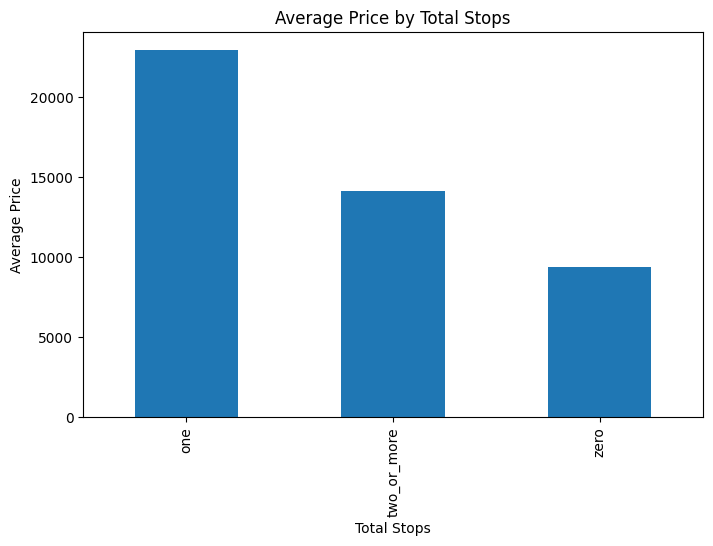

In [ ]:
plt.figure(figsize=(8, 5))
df.groupby('stops')['price'].mean().plot(kind='bar')
plt.xlabel('Total Stops')
plt.ylabel('Average Price')
plt.title('Average Price by Total Stops')
plt.show()

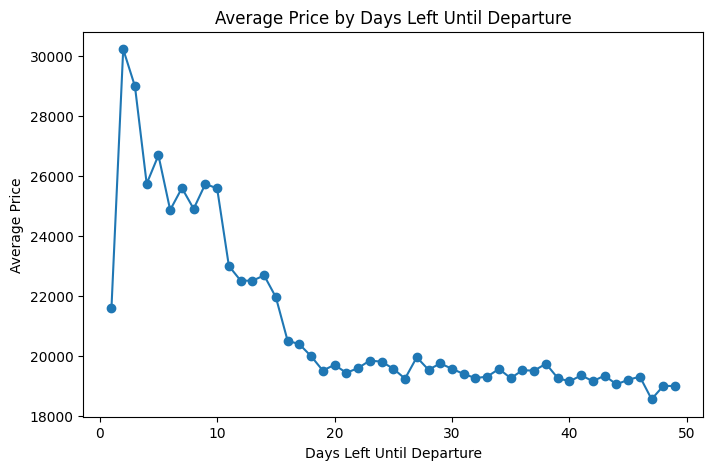

In [ ]:
days_left_price = df.copy()

plt.figure(figsize=(8, 5))
days_left_price.groupby('days_left')['price'].mean().plot(kind='line', marker='o')
plt.xlabel('Days Left Until Departure')
plt.ylabel('Average Price')
plt.title('Average Price by Days Left Until Departure')
plt.show()

In [ ]:
#featureengineering

stop_map = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}


if 'stops' in df.columns:
    df['Total_Stops'] = df['stops'].map(stop_map)
    print(f"Mapped 'stops' column to 'Total_Stops'. Unique values after mapping: {df['Total_Stops'].unique()}")
else:
    print("Warning: 'stops' column not found. Skipping 'Total_Stops' mapping.")

    df['Total_Stops'] = -1

print(f"The 'duration' column is already numeric. Example values: {df['duration'].head().tolist()}")


cols_to_display = []
if 'duration' in df.columns:
    cols_to_display.append('duration')
if 'Total_Stops' in df.columns:
    cols_to_display.append('Total_Stops')
if 'days_left' in df.columns:
    cols_to_display.append('days_left')

if cols_to_display:
    print("\nDisplaying head of engineered and relevant existing columns:")
    print(df[cols_to_display].head())
else:
    print("\nNo relevant columns to display after feature engineering.")

Mapped 'stops' column to 'Total_Stops'. Unique values after mapping: [0 1 2]
The 'duration' column is already numeric. Example values: [2.17, 2.33, 2.17, 2.25, 2.33]

Displaying head of engineered and relevant existing columns:
   duration  Total_Stops  days_left
0      2.17            0          1
1      2.33            0          1
2      2.17            0          1
3      2.25            0          1
4      2.33            0          1


In [ ]:
#making the data ready (drop columns)
df_model = df.drop(columns=[
    'departure_time',
    'arrival_time',
    'duration',
    'flight',
    'stops',
    'Unnamed: 0'
], errors='ignore').copy()

df_model.head()

,airline,source_city,destination_city,class,days_left,price,Total_Stops
0,SpiceJet,Delhi,Mumbai,Economy,1,5953,0
1,SpiceJet,Delhi,Mumbai,Economy,1,5953,0
2,AirAsia,Delhi,Mumbai,Economy,1,5956,0
3,Vistara,Delhi,Mumbai,Economy,1,5955,0
4,Vistara,Delhi,Mumbai,Economy,1,5955,0


In [ ]:
#convert categorical columns to numerical (booleanbased) (onehotencoding)
df_model = pd.get_dummies(
    df_model,
    columns=['airline', 'source_city', 'destination_city', 'class'], # Add 'class' here
    drop_first=True
)

df_model.head()

,days_left,price,Total_Stops,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,1,5953,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True
1,1,5953,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True
2,1,5956,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
3,1,5955,0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,True
4,1,5955,0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,True


In [ ]:
#trainingandtestingsplit (concept of overfitting and underfitting)
X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)

Training shape: (240122, 18)
Test shape: (60031, 18)


In [ ]:
#tries to assign to see how imp each attribute is for predicting the target variable)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print('Linear Regression Mean Absolute Error:', round(lr_mae, 2))
print('Linear Regression R-squared:', round(lr_r2, 4))


Linear Regression Mean Absolute Error: 4503.9
Linear Regression R-squared: 0.909


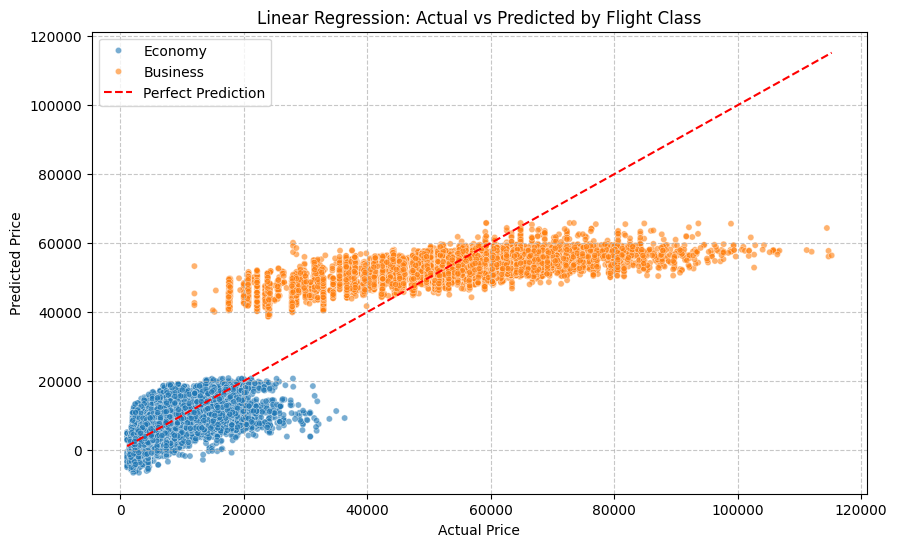

In [ ]:
plt.figure(figsize=(10, 6))

plot_df_lr = pd.DataFrame({
    'Actual Price': y_test,
    'LR Predicted': lr_preds
})

plot_df_lr['class_Economy'] = X_test['class_Economy']

plot_df_lr['Flight Class'] = plot_df_lr['class_Economy'].map({True: 'Economy', False: 'Business'})

sns.scatterplot(
    x='Actual Price',
    y='LR Predicted',
    hue='Flight Class',
    data=plot_df_lr,
    alpha=0.6,
    s=20
)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted by Flight Class')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
#randomforest eg: akinator game (checks and predicts based on y/n)
#captures complex patterns

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print('Random Forest Mean Absolute Error:', round(rf_mae, 2))
print('Random Forest R-squared:', round(rf_r2, 4))

Random Forest Mean Absolute Error: 2481.72
Random Forest R-squared: 0.958


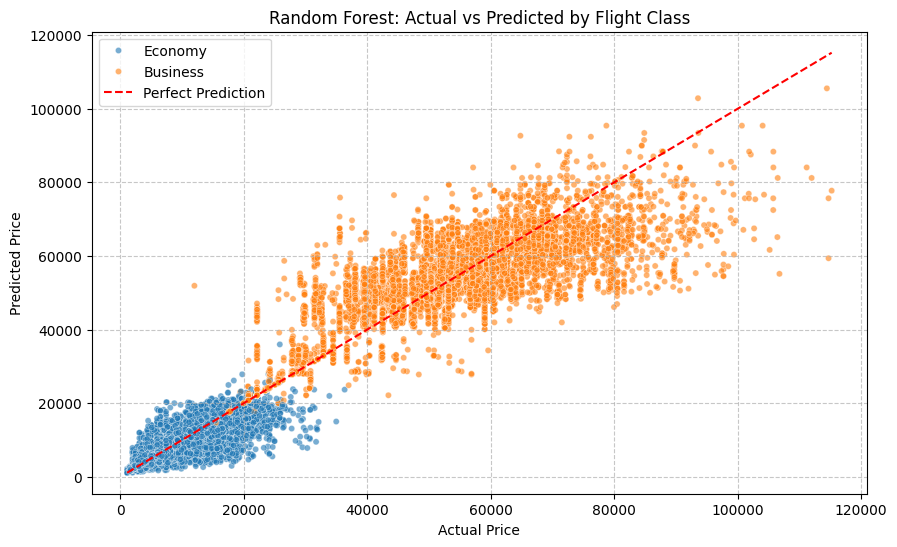

In [ ]:
plt.figure(figsize=(10, 6))

plot_df = pd.DataFrame({
    'Actual Price': y_test,
    'RF Predicted': rf_preds
})

plot_df['class_Economy'] = X_test['class_Economy']

plot_df['Flight Class'] = plot_df['class_Economy'].map({True: 'Economy', False: 'Business'})

sns.scatterplot(
    x='Actual Price',
    y='RF Predicted',
    hue='Flight Class',
    data=plot_df,
    alpha=0.6,
    s=20
)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted by Flight Class')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#comparing the both
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'R-squared': [lr_r2, rf_r2]
})

results_df

,Model,MAE,R-squared
0,Linear Regression,4503.895037,0.908978
1,Random Forest,2481.719890,0.958006


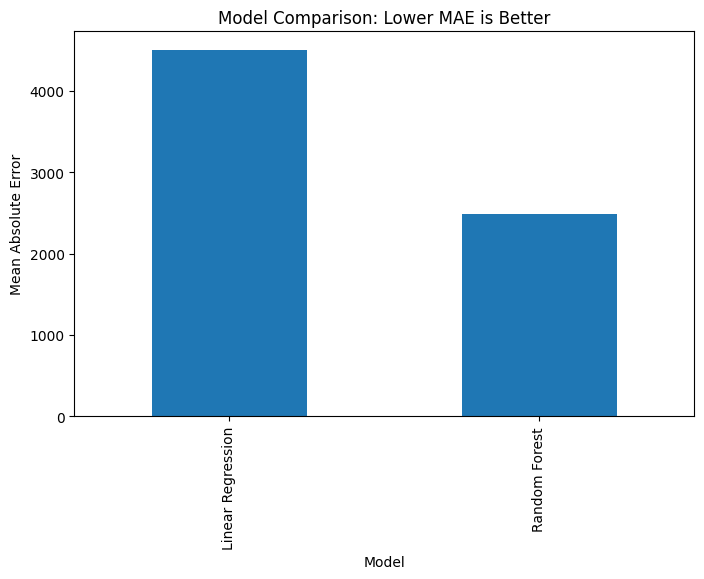

In [ ]:
results_plot = results_df.set_index('Model')

plt.figure(figsize=(8, 5))
results_plot['MAE'].plot(kind='bar')
plt.ylabel('Mean Absolute Error')
plt.title('Model Comparison: Lower MAE is Better')
plt.show()

In [ ]:
#randomforest gives closer prediction
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'LR Predicted': np.round(lr_preds, 0),
    'RF Predicted': np.round(rf_preds, 0)
})

comparison_df.head(10)


,Actual Price,LR Predicted,RF Predicted
0,7366,3966.0,5154.0
1,64831,54583.0,63468.0
2,6195,9576.0,6995.0
3,60160,55021.0,60219.0
4,6578,6828.0,6550.0
5,4555,9496.0,6198.0
6,23838,51187.0,23838.0
7,3860,6559.0,4287.0
8,32230,48292.0,48063.0
9,76841,57938.0,69665.0


In [ ]:
#feature importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(10)
feature_importance

,0
class_Economy,0.911858
Total_Stops,0.040203
days_left,0.015267
airline_Vistara,0.005554
airline_Air_India,0.005480
destination_city_Delhi,0.004193
source_city_Delhi,0.004142
source_city_Mumbai,0.002512
destination_city_Mumbai,0.002185
source_city_Kolkata,0.001977


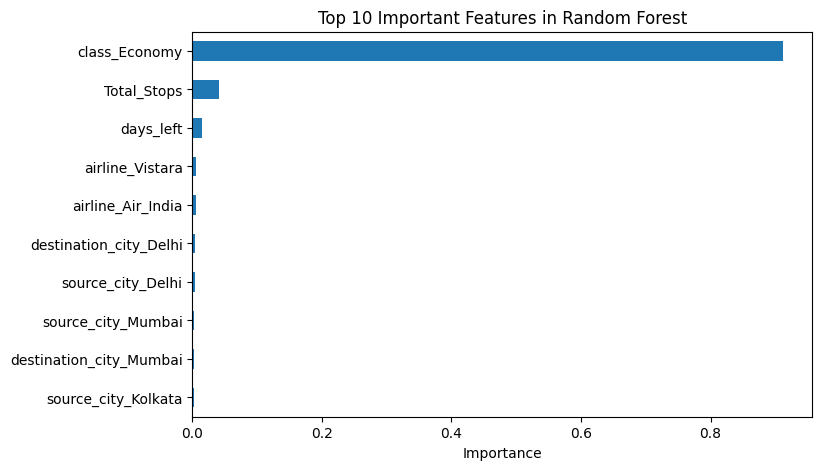

In [ ]:
#classeconomy is important
feature_importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.xlabel('Importance')
plt.title('Top 10 Important Features in Random Forest')
plt.show()


In [ ]:
days_before_departure = int(input("Enter days before departure: "))
duration_hours = float(input("Enter duration in hours: "))
stops = int(input("Enter number of stops (0, 1, 2): "))
demand_level = input("Enter demand level (Low, Medium, High): ")
airline = input("Enter airline (Airline A, Airline B, Airline C): ")

user_input = pd.DataFrame([{
    "days_before_departure": days_before_departure,
    "duration_hours": duration_hours,
    "stops": stops,
    "demand_level": demand_level,
    "airline": airline
}])

user_input_encoded = pd.get_dummies(user_input, columns=["demand_level", "airline"])
user_input_encoded = user_input_encoded.reindex(columns=X.columns, fill_value=0)

lr_prediction = lr_model.predict(user_input_encoded)[0]
rf_prediction = rf_model.predict(user_input_encoded)[0]

print(f"Linear Regression prediction: {lr_prediction:.2f}")
print(f"Random Forest prediction: {rf_prediction:.2f}")

Enter days before departure: 3
Enter duration in hours: 2
Enter number of stops (0, 1, 2): 0
Enter demand level (Low, Medium, High): High
Enter airline (Airline A, Airline B, Airline C): Airline B
Linear Regression prediction: 47411.66
Random Forest prediction: 33004.65
